In [1]:
#Lets have matplotlib "inline"
%matplotlib inline

#Import packages we need
import numpy as np
import gc
from matplotlib import animation, rc
from matplotlib import pyplot as plt
from matplotlib import gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
#import mpld3

import miscPlotting

try:
    from StringIO import StringIO
except ImportError:
    from io import StringIO

from common_simulator import *

# matplotlib global options here:
# usetex=True
# bbox tight
# text.size, figure.size

In [2]:
simulators = [LxF.LxF, FORCE.FORCE, HLL.HLL, HLL2.HLL2, KP07.KP07, KP07_dimsplit.KP07_dimsplit, WAF.WAF]

In [3]:
# ic can be bump, dambreak, or constant. Pass through papermill with `-p ic bump`
ic:str = 'bump'


In [4]:
# Parameters
ic = "bump"


In [5]:
print(f'ic = {ic}')

ic = bump


In [6]:
simulators = [LxF.LxF, FORCE.FORCE, HLL.HLL, HLL2.HLL2, KP07.KP07, KP07_dimsplit.KP07_dimsplit, WAF.WAF]
domain_sizes = np.loadtxt('domain_sizes.csv').transpose().astype(int)
ref_file_size = domain_sizes[-1]
domain_sizes = domain_sizes[:-1]
ref_file = lambda simulator: gen_filename(None,
                     nx=ref_file_size[0],
                     ny=ref_file_size[1],
                     prefix="space", ic=ic, simulator=simulator.__name__)

# Run the simulators

In [7]:
# Space calculations
'''
for simulator in simulators:
    commands = 'python calculator_simulator.py'.split(' ')
    commands += ['space']
    commands += [ic]
    commands += [simulator.__name__]
    commands += ['--ref', f'{ref_file(simulator)}']
    commands += ['--sizes']
    commands += [f'{nx}_{ny}' for nx,ny in domain_sizes]
    subprocess.run(commands).check_returncode()
'''
# Time calculations
'''
for simulator in simulators:
    commands = 'python calculator_simulator.py'.split(' ')
    commands += ['time']
    commands += [ic]
    commands += [simulator.__name__]
    commands += ['--sizes']
    commands += [f'{nx}_{ny}' for nx,ny in domain_sizes]
    subprocess.run(commands, check=True)
'''

"\nfor simulator in simulators:\n    commands = 'python calculator_simulator.py'.split(' ')\n    commands += ['time']\n    commands += [ic]\n    commands += [simulator.__name__]\n    commands += ['--sizes']\n    commands += [f'{nx}_{ny}' for nx,ny in domain_sizes]\n    subprocess.run(commands, check=True)\n"

## Load data

In [8]:
time_ds_x, time_ds_y = [], []
space_ds_x, space_ds_y = [], []
megacells_per_sec = []
peak_megacells_per_sec = np.zeros(len(simulators))
sim_errors = []
sim_cons = []
sim_nt = []
longsim_nt = []
sim_tf = []
longsim_tf = []
longsim_elapsed_time = []

for  i, simulator in enumerate(simulators):
    # time data
    filename = gen_results_filename('time', simulator.__name__, ic)
    with np.load(filename) as d:
        order = np.argsort(d['ds_x'])
        time_ds_x.append(d['ds_x'][order])
        time_ds_y.append(d['ds_y'][order])
        megacells_per_sec.append(d['megacells_per_sec'][order])
        peak_megacells_per_sec[i] = d['peak_megacells_per_sec']
        longsim_nt.append(d['sim_nt'])
        longsim_tf.append(d['sim_tf'][order])
        longsim_elapsed_time.append(d['longsim_elapsed_time'][order])

    # space data
    filename = gen_results_filename('space', simulator.__name__, ic)
    with np.load(filename) as d:
        order = np.argsort(d['ds_x'])
        space_ds_x.append(d['ds_x'][order])
        space_ds_y.append(d['ds_y'][order])
        sim_errors.append(d['sim_errors'][order])
        sim_cons.append(d['sim_cons'][order])
        sim_nt.append(d['sim_nt'][order])
        sim_tf.append(d['sim_tf'])

# Reduce orders for redundant data
time_ds_x = np.array(time_ds_x)
time_ds_y = np.array(time_ds_y)
space_ds_x = np.array(space_ds_x)
space_ds_y = np.array(space_ds_y)
assert np.all(time_ds_x == space_ds_x) 
assert np.all(time_ds_y == space_ds_y) 

assert np.all(time_ds_x == time_ds_x[0]) 
#assert np.all(time_ds_y == time_ds_y[0]) 
ds_x = time_ds_x#[0]
ds_y = time_ds_y#[0]


megacells_per_sec = np.array(megacells_per_sec)
sim_errors = np.array(sim_errors)
sim_cons = np.array(sim_cons)
sim_nt = np.array(sim_nt)
longsim_tf = np.array(longsim_tf)

assert np.all(sim_tf == sim_tf[0])
sim_tf = sim_tf[0]
assert np.all(longsim_nt == longsim_nt[0])
longsim_nt = longsim_nt[0]

gc.collect()

693

# Initial condition

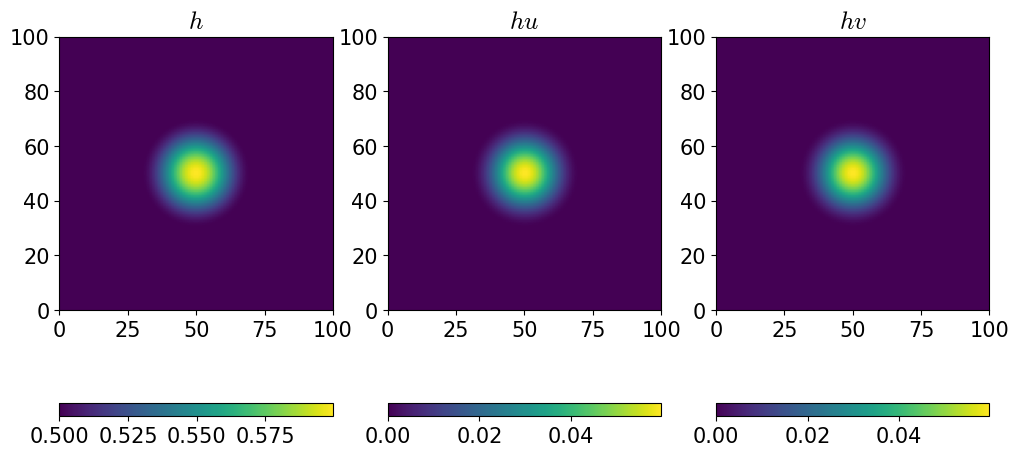

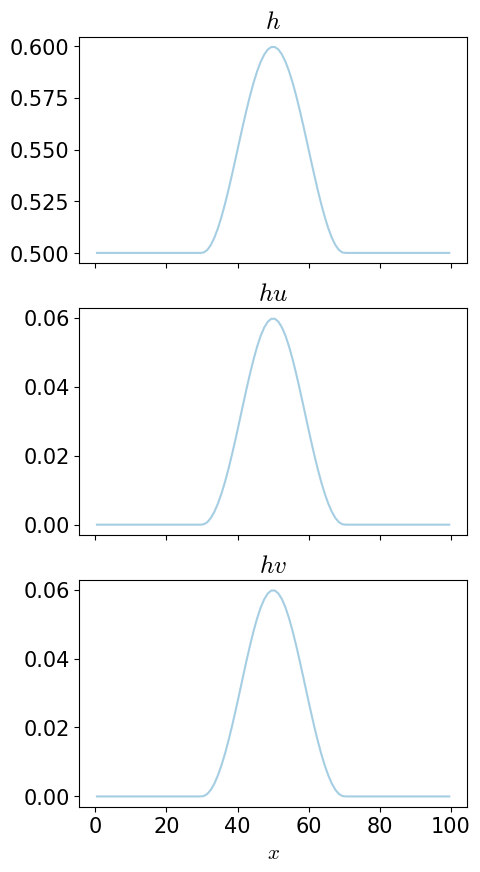

In [9]:
width = 50
height = width
nx = ny = 100
test_data_args = {
            'nx': nx,
            'ny': ny,
            'ref_nx': 1000,
            'ref_ny': 1000,
            'num_ghost_cells': GetSimulator.num_ghost_cells[simulator.__name__]
}
# This will change according to the init
test_data_args.update(GetInitialCondition.ics[ic]['test_data_args'])
h, hu, hv, dx, dy, = GetInitialCondition.ics[ic]['fn'](**test_data_args)

# The 2D plots are for verification only
fig = plt.figure()
ax=plt.subplot(1,3,1)
im=plt.imshow(h, extent=[0, nx*dx, 0, ny*dy])
plt.title("$h$")
plt.colorbar(orientation='horizontal')

ax=plt.subplot(1,3,2)
im=plt.imshow(hu, extent=[0, nx*dx, 0, ny*dy])
plt.title("$hu$")
plt.colorbar(orientation='horizontal')

ax=plt.subplot(1,3,3)
im=plt.imshow(hv, extent=[0, nx*dx, 0, ny*dy])
plt.title("$hv$")
plt.colorbar(orientation='horizontal')

ngc = (h.shape[1] - nx)/2
x = np.arange((1 - ngc - 0.5) * dx, (nx + ngc - 0.5)* dx + dx, dx)
j = ny//2
fig = plt.figure(figsize=(5,10))
fig.subplots(3,1, sharex=True)
ax=plt.subplot(3,1,1)
miscPlotting.setBwStyles(ax)
im=plt.plot(x, h[j], '-')
plt.title("$h$")

ax=plt.subplot(3,1,2)
miscPlotting.setBwStyles(ax)
im=plt.plot(x, hu[j], '-')
plt.title("$hu$")

ax=plt.subplot(3,1,3)
miscPlotting.setBwStyles(ax)
im=plt.plot(x, hv[j], '-')
plt.title("$hv$")
ax.set_xlabel("$x$")

miscPlotting.save_figure(fig, "ic", ic)

# Performance

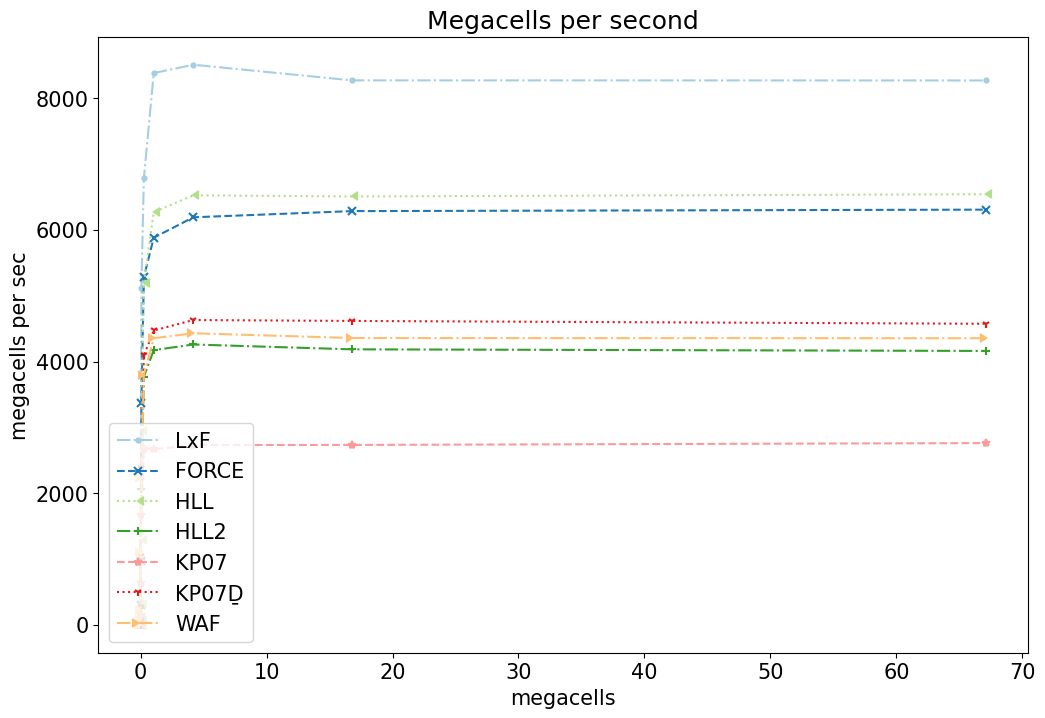

In [10]:
fig = plt.figure()

miscPlotting.setBwStyles(fig.gca())
for i, simulator in enumerate(simulators):
    plt.plot(ds_x[i] * ds_y[i] * 10**-6, megacells_per_sec[i], label = simulator.label())
    plt.xlabel("megacells")
    plt.ylabel("megacells per sec")
plt.legend(loc="lower left")
plt.title("Megacells per second")
miscPlotting.save_figure(fig, "megacells_per_second", ic)

0 <class 'GPUSimulators.LxF.LxF'> 8348.496099077389
1 <class 'GPUSimulators.FORCE.FORCE'> 6260.35372962385
2 <class 'GPUSimulators.HLL.HLL'> 6523.870962492376
3 <class 'GPUSimulators.HLL2.HLL2'> 4201.214866273925
4 <class 'GPUSimulators.KP07.KP07'> 2741.9856423580372
5 <class 'GPUSimulators.KP07_dimsplit.KP07_dimsplit'> 4606.345960506267
6 <class 'GPUSimulators.WAF.WAF'> 4379.776561499032


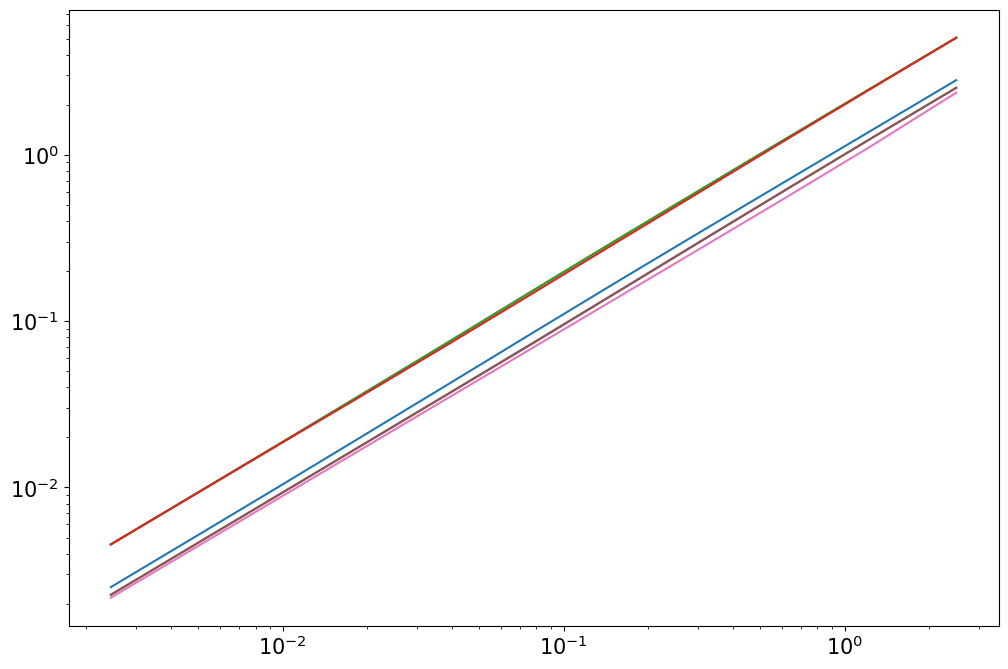

In [11]:
longsim_average_dt = longsim_tf / longsim_nt
sim_average_dt = sim_tf / sim_nt
for i, simulator in enumerate(simulators):
    print(i, simulator, peak_megacells_per_sec[i])
    plt.loglog(20/ds_x[i], longsim_average_dt[i])

# Peak performance

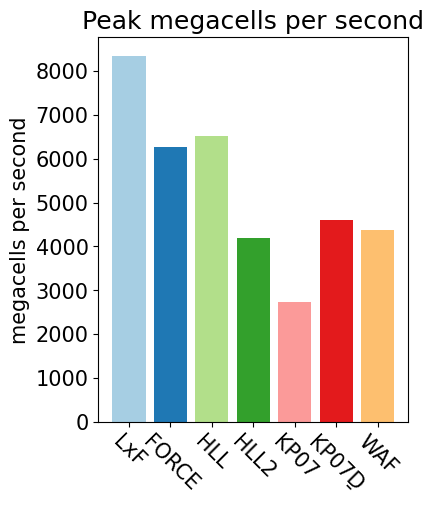

In [12]:
import seaborn as sns
fig = plt.figure(figsize=(4,5))
miscPlotting.setBwStyles(fig.gca())
plt.bar([sim.label() for sim in simulators], peak_megacells_per_sec, color=sns.color_palette("Paired", 7))
plt.ylabel("megacells per second")
plt.title("Peak megacells per second")
plt.tick_params('x', rotation=-45)
miscPlotting.save_figure(fig, "peak_megacells_per_second", ic)

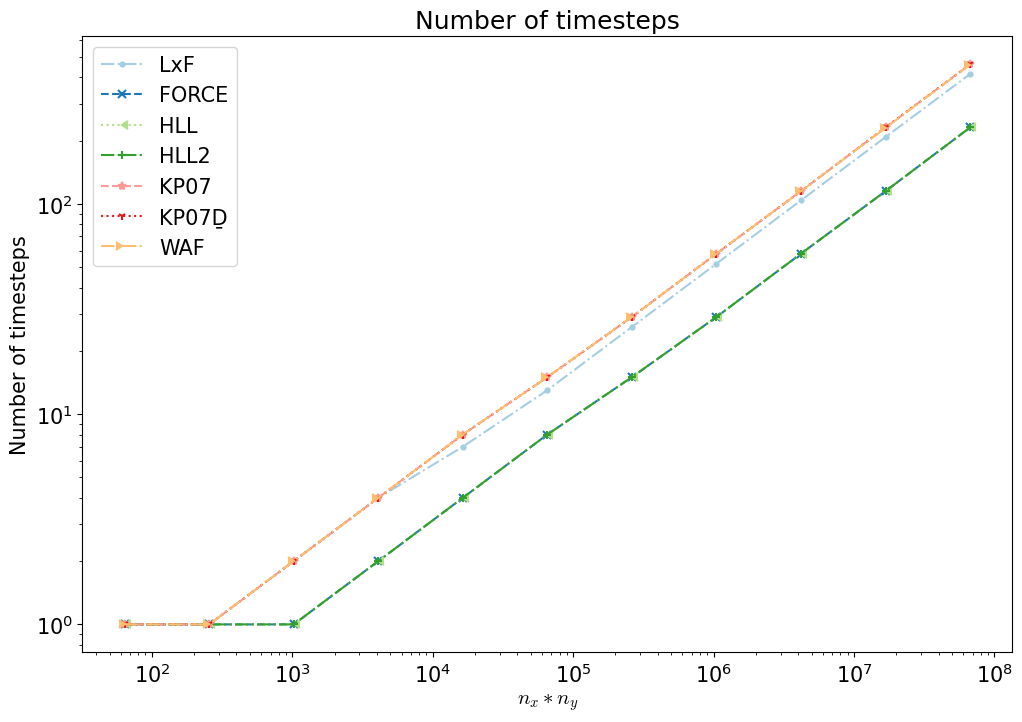

In [13]:
fig = plt.figure()

miscPlotting.setBwStyles(fig.gca())
for i, simulator in enumerate(simulators):
    plt.loglog(ds_x[i] * ds_y[i], sim_nt[i], label = simulator.label())
    plt.xlabel("$n_x * n_y$")
    plt.ylabel("Number of timesteps")
plt.legend()
plt.title("Number of timesteps")
miscPlotting.save_figure(fig, "number_of_timesteps", ic)

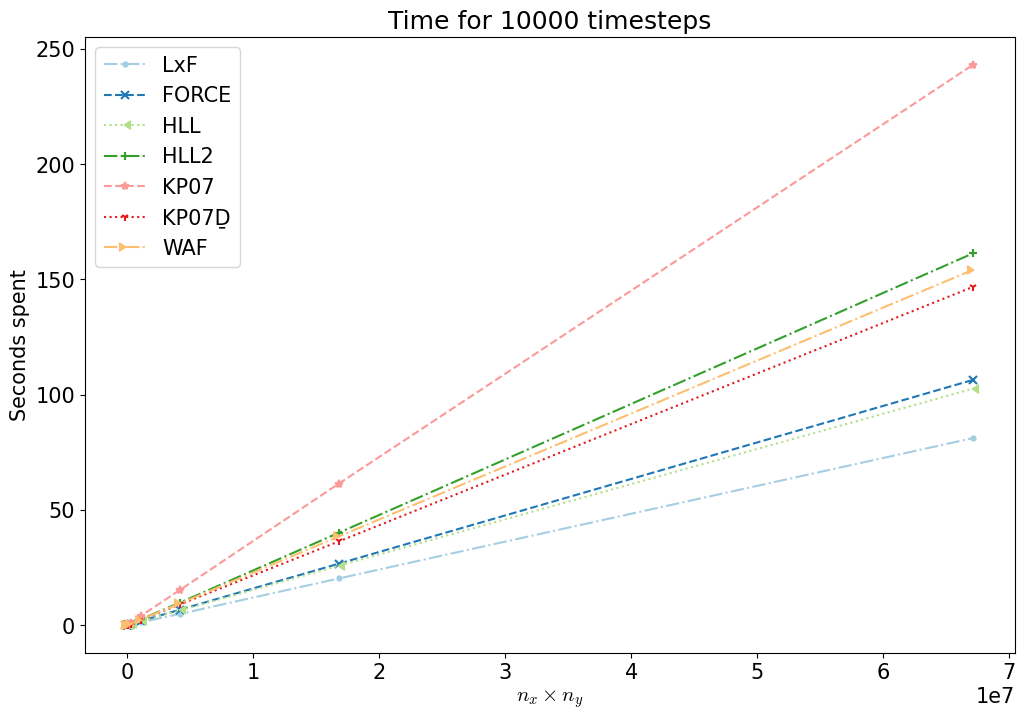

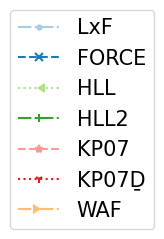

In [14]:
fig = plt.figure()

miscPlotting.setBwStyles(fig.gca())
for i, simulator in enumerate(simulators):
    plt.plot(ds_x[i] * ds_y[i], longsim_elapsed_time[i], label = f"{simulator.label()}")
    plt.xlabel("$n_x\\times n_y$")
    plt.ylabel("Seconds spent")
plt.legend()
plt.title(f"Time for {longsim_nt.astype(int)} timesteps")
miscPlotting.save_figure(fig, "time_spent_for_bignumber_timesteps", ic)

figLegend = plt.figure(figsize=(1.5, 1.3))
plt.plot(0,0)
plt.figlegend(*fig.gca().get_legend_handles_labels(), loc='center')
plt.axis('off')
miscPlotting.save_figure(figLegend, "common_legend", ic)

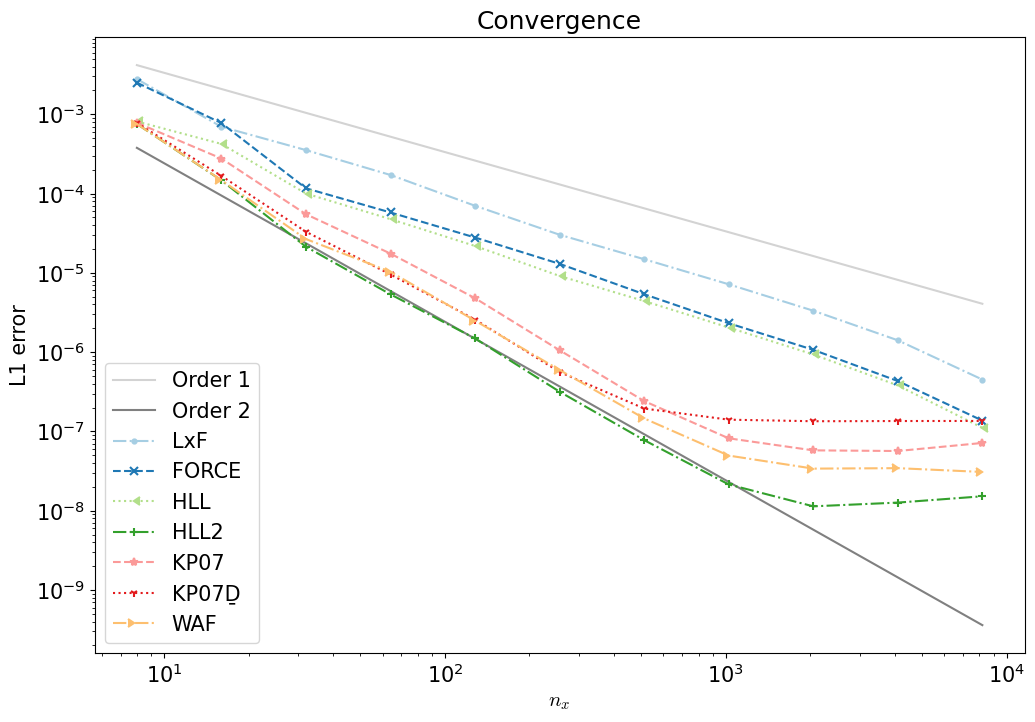

In [15]:
fig = plt.figure()
x_axis_start = np.min(ds_x)
if ic == 'bump':
    # Orders are 1 and 2
    scaling = np.max(sim_errors[:,0]) * 1.5 * x_axis_start
    plt.plot(ds_x[0], scaling / np.array(ds_x[0]), '-', c='lightgray', label='Order 1')
    scaling = np.min(sim_errors[:,0]) * 0.5 * x_axis_start ** 2
    plt.plot(ds_x[0], scaling / np.power(ds_x[0], 2), '-', c='gray', label='Order 2')
if ic == 'dambreak':
    # Orders are 0.5 and 1
    scaling = np.max(sim_errors[:,0]) * 1.5 * x_axis_start ** 0.5
    plt.plot(ds_x[0], scaling / np.power(ds_x[0], 0.5), '-', c='lightgray', label='Order 0.5')
    scaling = np.min(sim_errors[:,0]) * 0.5 * x_axis_start ** 1
    plt.plot(ds_x[0], scaling / np.power(ds_x[0], 1), '-', c='gray', label='Order 1')

miscPlotting.setBwStyles(fig.gca())
for i, simulator in enumerate(simulators):
    plt.loglog(ds_x[i,:], sim_errors[i,:], label = simulator.label())
    plt.xlabel("$n_x$")
    plt.ylabel("L1 error")
plt.legend()
plt.title("Convergence")
miscPlotting.save_figure(fig, "convergence_rate", ic)

# Conservation error

Text(0.5, 1.0, 'Conservation error')

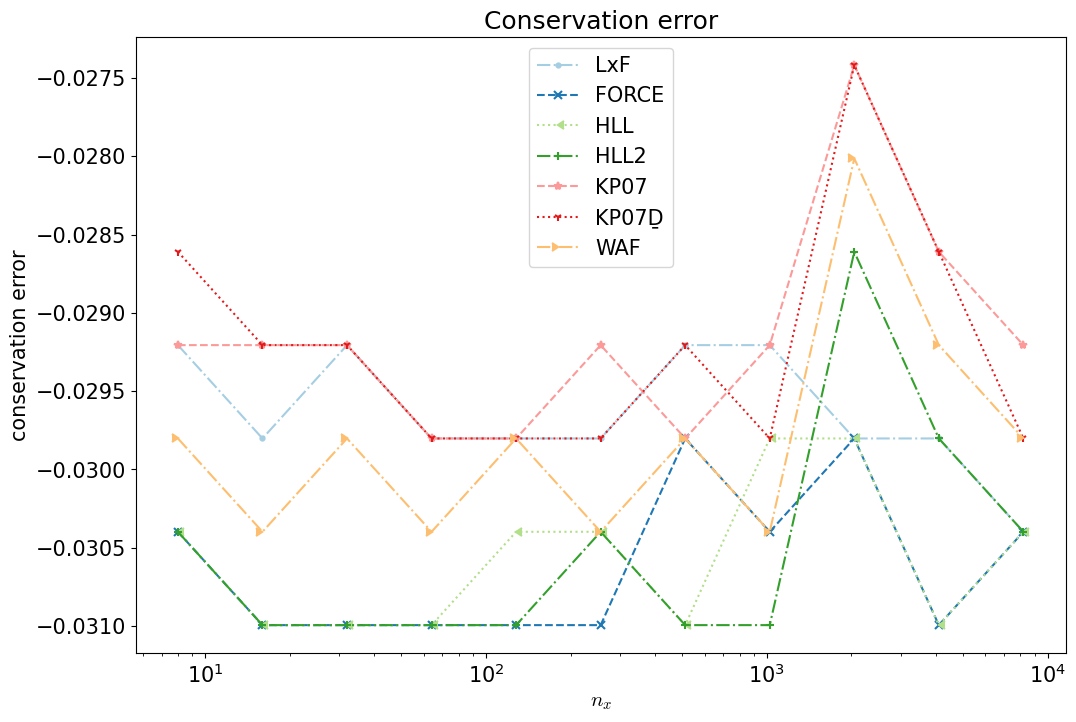

In [16]:
fig = plt.figure()
x_axis_start = np.min(ds_x)

miscPlotting.setBwStyles(fig.gca())
for i, simulator in enumerate(simulators):
    plt.semilogx(ds_x[i,:], sim_cons[i,:], label = simulator.label())
    plt.xlabel("$n_x$")
    plt.ylabel("conservation error")
plt.legend()
plt.title("Conservation error")
# miscPlotting.save_figure(fig, "conservation_error", ic)

## Peak performance vs rate of convergence

,8.0,16.0,32.0,64.0,128.0,256.0,512.0,1024.0,2048.0,4096.0
LxF,1.998055,0.978616,1.042440,1.289654,1.214314,1.024802,1.051022,1.107180,1.239644,1.645352
FORCE,1.693376,2.732566,1.013401,1.049348,1.103133,1.272039,1.216304,1.114251,1.307670,1.657566
HLL,0.943054,2.078052,1.073513,1.123619,1.257062,1.049705,1.110231,1.129366,1.297930,1.774922
HLL2,2.366323,2.781928,1.994947,1.846741,2.232847,2.028404,1.856557,0.917676,-0.156412,-0.264070
KP07,1.499801,2.333361,1.649717,1.868909,2.181097,2.129757,1.561064,0.504704,0.027053,-0.337180
KP07Ḏ,2.220265,2.341675,1.787296,1.891200,2.195813,1.531243,0.467398,0.065532,-0.008651,-0.003488
WAF,2.355113,2.467694,1.372619,2.045723,2.067852,2.029060,1.557833,0.545898,-0.019161,0.159113


,Max,Min,Mean,Median
LxF,1.998055,0.978616,1.228415,1.046731
FORCE,2.732566,1.013401,1.440024,1.159718
HLL,2.078052,0.943054,1.233605,1.116925
HLL2,2.781928,-0.264070,2.158250,2.011676
KP07,2.333361,-0.337180,1.889101,1.999333
KP07Ḏ,2.341675,-0.008651,1.776413,1.839248
WAF,2.467694,-0.019161,1.985128,2.037391


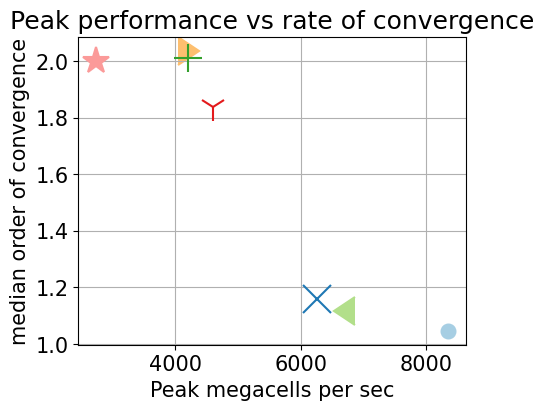

In [17]:
order = np.zeros((ds_x.shape[0], ds_x.shape[1]-1))
for i, sim in enumerate(simulators):
    order[i, :] = np.log2(sim_errors[i,:-1]/sim_errors[i,1:])

fig = plt.figure(figsize=(5,4))
miscPlotting.setBwStyles(fig.gca())
plt.title("Peak performance vs rate of convergence")
for i, sim in enumerate(simulators):
    l = plt.plot(peak_megacells_per_sec[i], np.median(order[i,1:-3]), label=sim.label(), markersize=20, linewidth=1e-5)#, color=sns.color_palette("Paired", 8)[i])
# this l will be the WAF _line_, which we want to be below the HLL2 marker
l[0].set_zorder(0)
plt.xlabel("Peak megacells per sec")
plt.ylabel("median order of convergence")
plt.grid()
# Common legend
# plt.legend(scatterpoints=1, scatteryoffsets=[0.5], markerscale=0.8)

import pandas as pd
from IPython.display import display
table = pd.DataFrame(order, columns=ds_x[0,:-1], index=[simulator.label() for simulator in simulators])
display(table)

order_summary = pd.DataFrame(np.empty((len(simulators), 4)), columns=['Max', 'Min', 'Mean', 'Median'], index=[simulator.label() for simulator in simulators])
for i, simulator in enumerate(simulators):
    order_summary.loc[simulator.label()] = [
        np.max(order[i,:]), 
        np.min(order[i,:]), 
        np.mean(order[i,:-3]), 
        np.median(order[i,1:-3])]
display(order_summary)

miscPlotting.save_figure(fig, "peak_perf_vs_convergence_rate", ic)



# Convergence multiplied by peak perf

Text(0, 0.5, 'peak perf-conv rate')

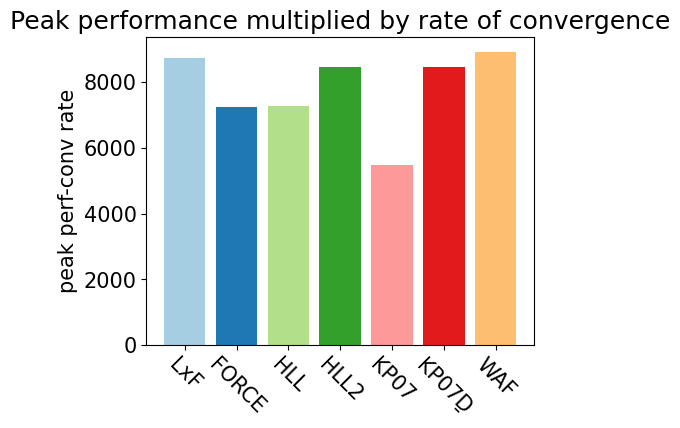

In [18]:
order = np.zeros((ds_x.shape[0], ds_x.shape[1]-1))
median_order = np.zeros((ds_x.shape[0]))
for i, sim in enumerate(simulators):
    order[i, :] = np.log2(sim_errors[i,:-1]/sim_errors[i,1:])
    median_order[i] = np.median(order[i,1:-3])

fig = plt.figure(figsize=(5,4))
miscPlotting.setBwStyles(fig.gca())
plt.title("Peak performance multiplied by rate of convergence")
plt.bar([sim.label() for sim in simulators], peak_megacells_per_sec * median_order, color=sns.color_palette("Paired", 7))
plt.tick_params('x', rotation=-45)
plt.ylabel("peak perf-conv rate")

In [19]:
IGNORE_LEFTMOST = 2

## Time vs absolute error plot

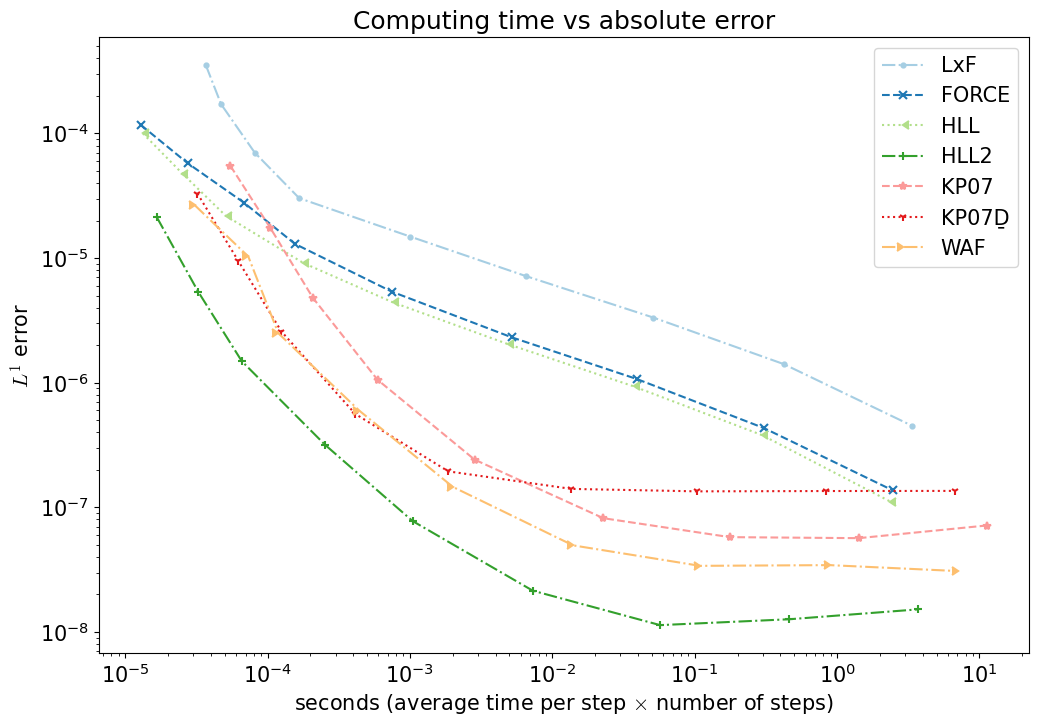

In [20]:
# Plot the timing and error data
secs_per_timestep = longsim_elapsed_time / longsim_nt
fig = plt.figure()
miscPlotting.setBwStyles(fig.gca())
plt.title("Computing time vs absolute error")

for i, simulator in enumerate(simulators):
    plt.loglog(secs_per_timestep[i,IGNORE_LEFTMOST:] * sim_nt[i,IGNORE_LEFTMOST:], sim_errors[i,IGNORE_LEFTMOST:], label = simulator.label())
    plt.ylabel("$L^1$ error")
    plt.xlabel("seconds (average time per step $\\times$ number of steps)")

plt.legend()
miscPlotting.save_figure(fig, "time_vs_absolute_error", ic)

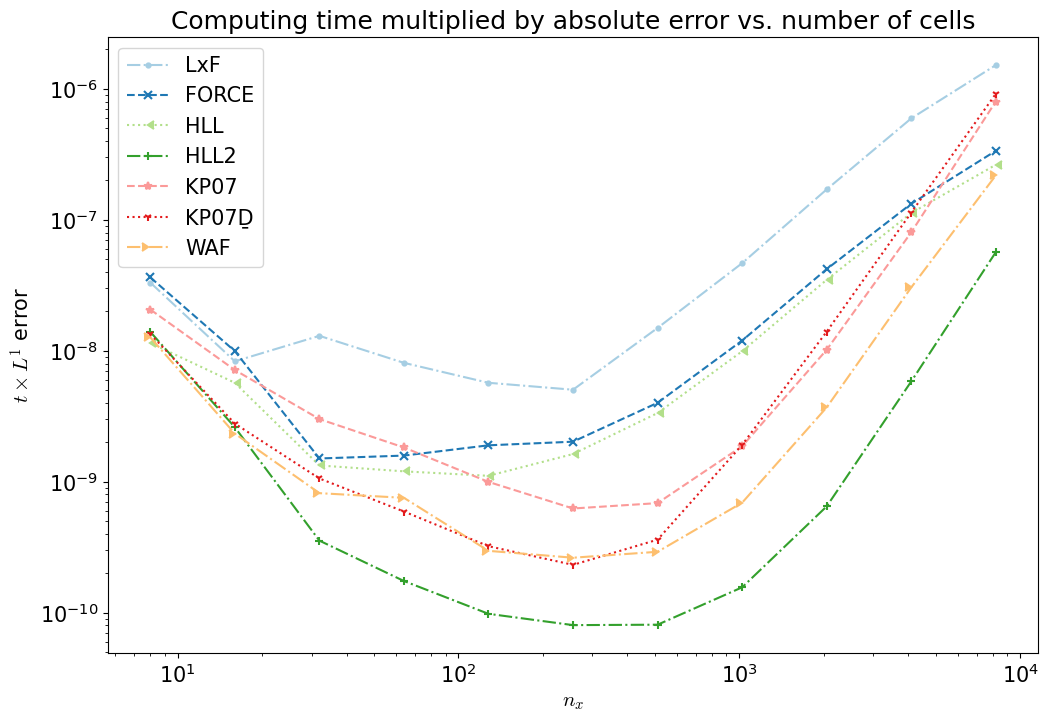

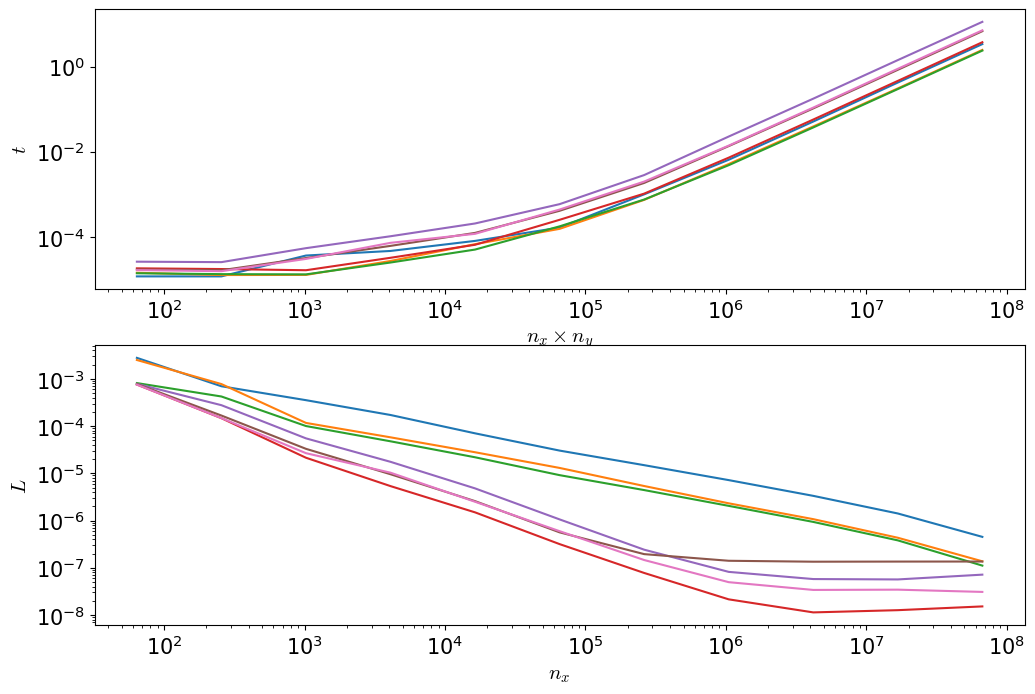

In [21]:
# Plot of whether time or error wins as grids become smaller
secs_per_timestep = longsim_elapsed_time / longsim_nt
fig = plt.figure()
miscPlotting.setBwStyles(fig.gca())
plt.title("Computing time multiplied by absolute error vs. number of cells")

for i, simulator in enumerate(simulators):
    plt.loglog(ds_x[i,:], secs_per_timestep[i,:] * sim_nt[i,:] * sim_errors[i,:], label = simulator.label())
    plt.xlabel("$n_x$")
    plt.ylabel("$t \\times L^1$ error")

plt.legend()
miscPlotting.save_figure(fig, "t_times_absolute_error", ic)

fig, (ax1, ax2) = plt.subplots(2, sharex=False)
for i, simulator in enumerate(simulators):
    ax1.loglog(ds_x[i,:] * ds_y[i,:], secs_per_timestep[i,:] * sim_nt[i,:], label=simulator.label())
    ax2.loglog(ds_x[i,:] * ds_y[i,:], sim_errors[i,:], label=simulator.label())
    ax1.set_xlabel("$n_x\\times n_y$")
    ax1.set_ylabel("$t$")
    ax2.set_xlabel("$n_x$")
    ax2.set_ylabel("$L$")
miscPlotting.save_figure(fig, "t_and_absolute_error_subplots", ic)

## Solution plots

In [22]:
def plot_solution(simulator, nx:int, ny:int, label, **kwargs):
    datafilename = gen_filename(None, nx, ny, ic=ic, simulator=simulator.__name__, prefix='space')
    
    #Read the solution
    with np.load(datafilename) as data:
        h = data['h']
        dx = data['dx']
        dy = data['dy']
        
    width = GetInitialCondition.ics[ic]['test_data_args']['width']
    x = 0.0 + dx * np.linspace(0.5, nx-0.5, nx)
    y = h[int(h.shape[0]/2),:]
    
    plt.plot(x, y, label=label, **kwargs)
    
    h = None
    x = None
    gc.collect() # Force 

def plot_reference(label="Reference", **kwargs):
    if ic == 'dambreak':
        ref_x, ref_h, _ = miscPlotting.gen_reference(4096)
        plt.plot(ref_x, ref_h, label=label, **kwargs)
    elif ic == 'bump':
        ref_xx,  ref_yy, ref_h, _, _ = miscPlotting.gen_reference(1024, ic = 'bump')
        ny = ref_xx.shape[0]
        assert(np.all(ref_yy[ny//2] == ref_yy[ny//2, 0]))
        plt.plot(ref_xx[0], ref_h[ny//2],  label=label, **kwargs)

def plot_comparison(NX = 512, **kwargs):
    if ic == 'dambreak':
        plot_reference(label='Analytic', color='black', ls='-')
    elif ic == 'bump':
        plot_reference(label='Reference', color='black', ls='-', lw=0.5)
    for i, simulator in enumerate(simulators):
        plot_solution(simulator, NX, NX, label=simulator.label(), **kwargs)
    gc.collect()

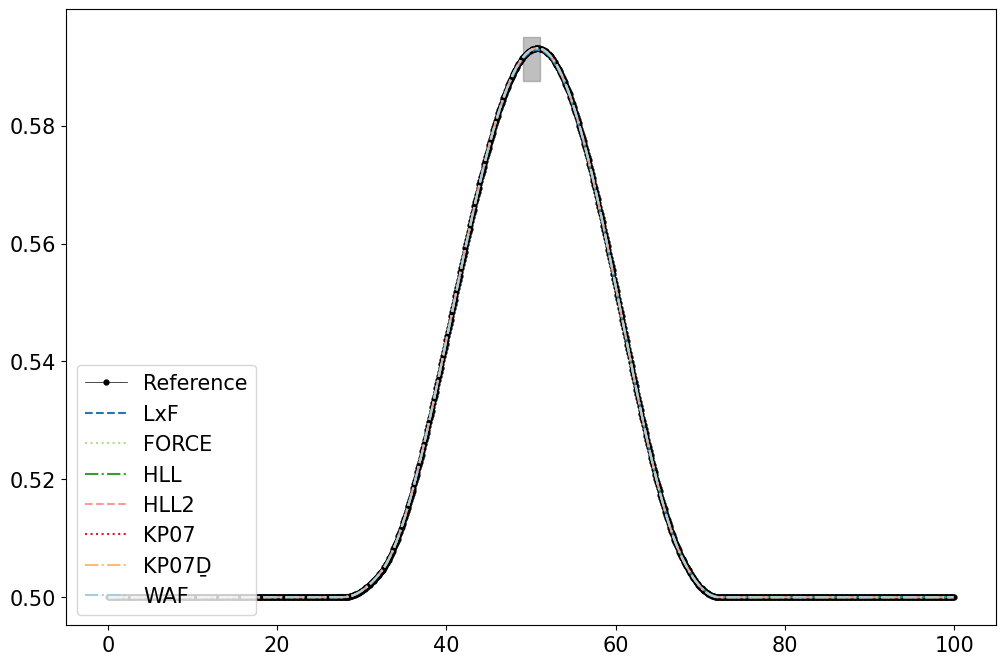

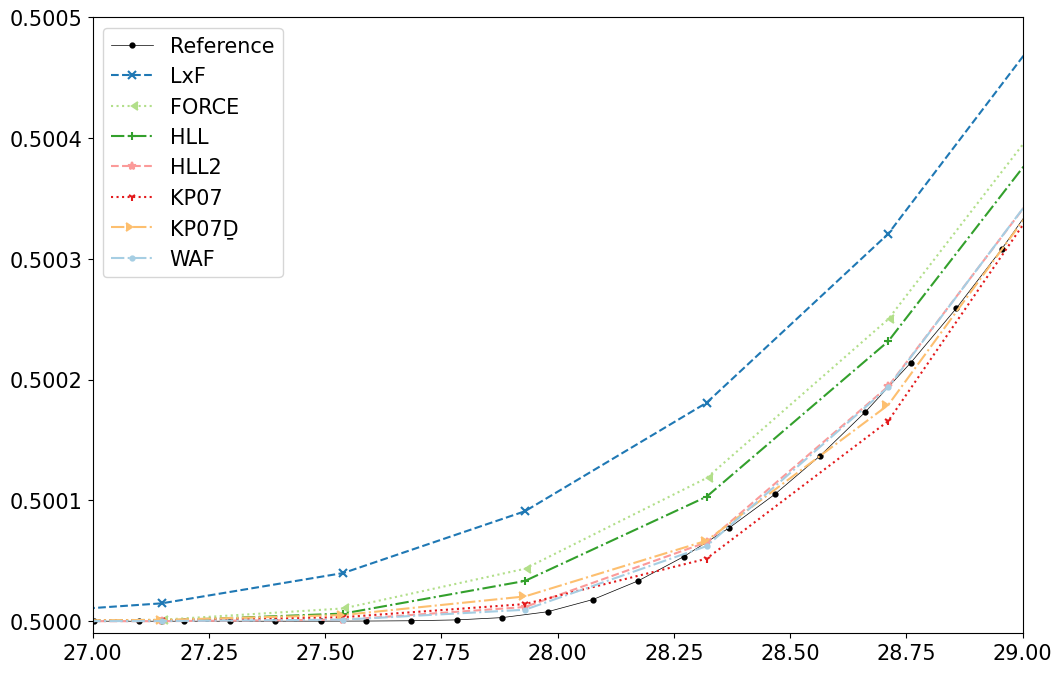

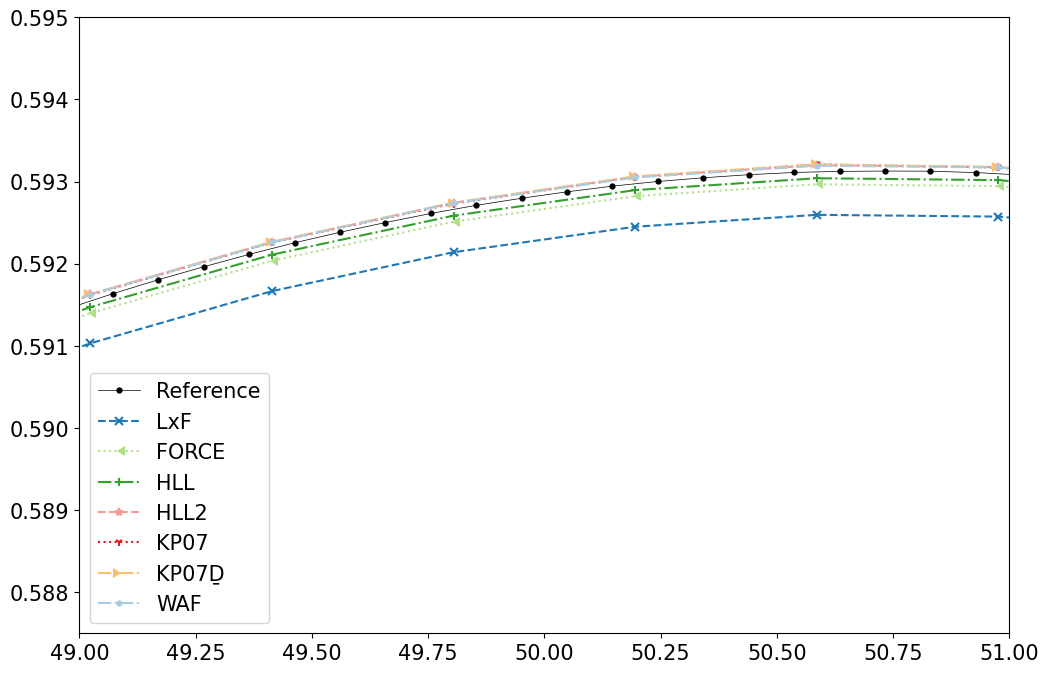

In [23]:
# Zoom plot boxes and NX to use for the numerical solutions
if ic == 'dambreak':
    boxes = np.array([\
            [[3.5, 4.1], [0.0044, 0.00505]], \
            [[4.7, 5.05], [0.0025, 0.0027]],  \
            [[6.1, 6.40], [0.0009, 0.0026]], \
            [[3.65, 4.85], [0.0025, 0.00505]], \
            ])
    NX = 256
elif ic == 'bump':
    boxes = np.array([\
         [[27, 29], [0.49999, 0.50050]], \
         [[49, 51], [0.5875, 0.595]]
         ])
    NX = 256
fig = plt.figure()
miscPlotting.setBwStyles(fig.gca())
plot_comparison(marker=' ')

for box_x, box_y in boxes:
    x = np.kron(box_x, np.ones((2)))
    y = np.hstack((box_y, box_y[::-1]))
    fig.gca().fill(x, y, fill=True, linestyle='-', color='gray', alpha=0.5)
plt.legend(loc='lower left')
miscPlotting.save_figure(fig, 'solution_wide', ic)

for i, bbox in enumerate(boxes):
    fig = plt.figure()
    miscPlotting.setBwStyles(fig.gca())
    plot_comparison(NX)
    plt.xlim(bbox[0])
    plt.ylim(bbox[1])
    plt.legend()
    miscPlotting.save_figure(fig, "solution_zoom_" + str(i), ic)


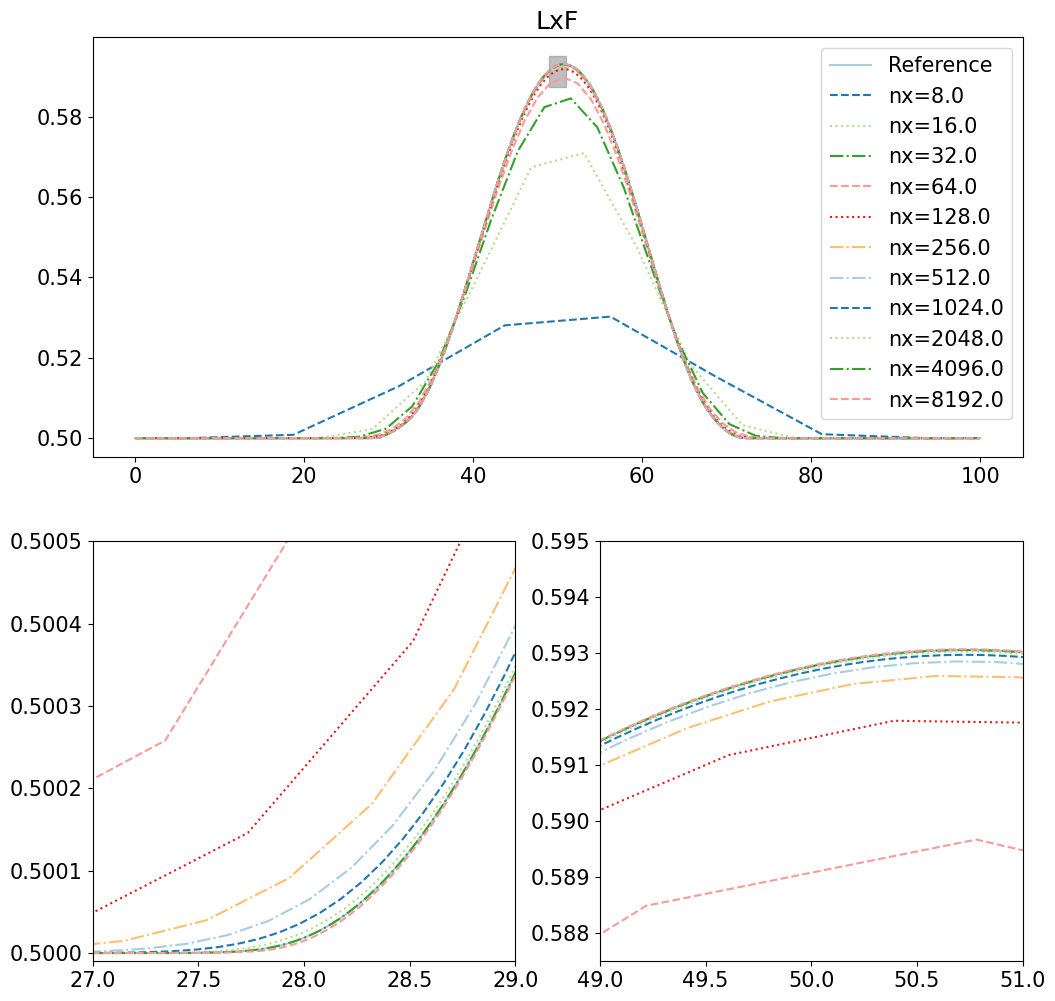

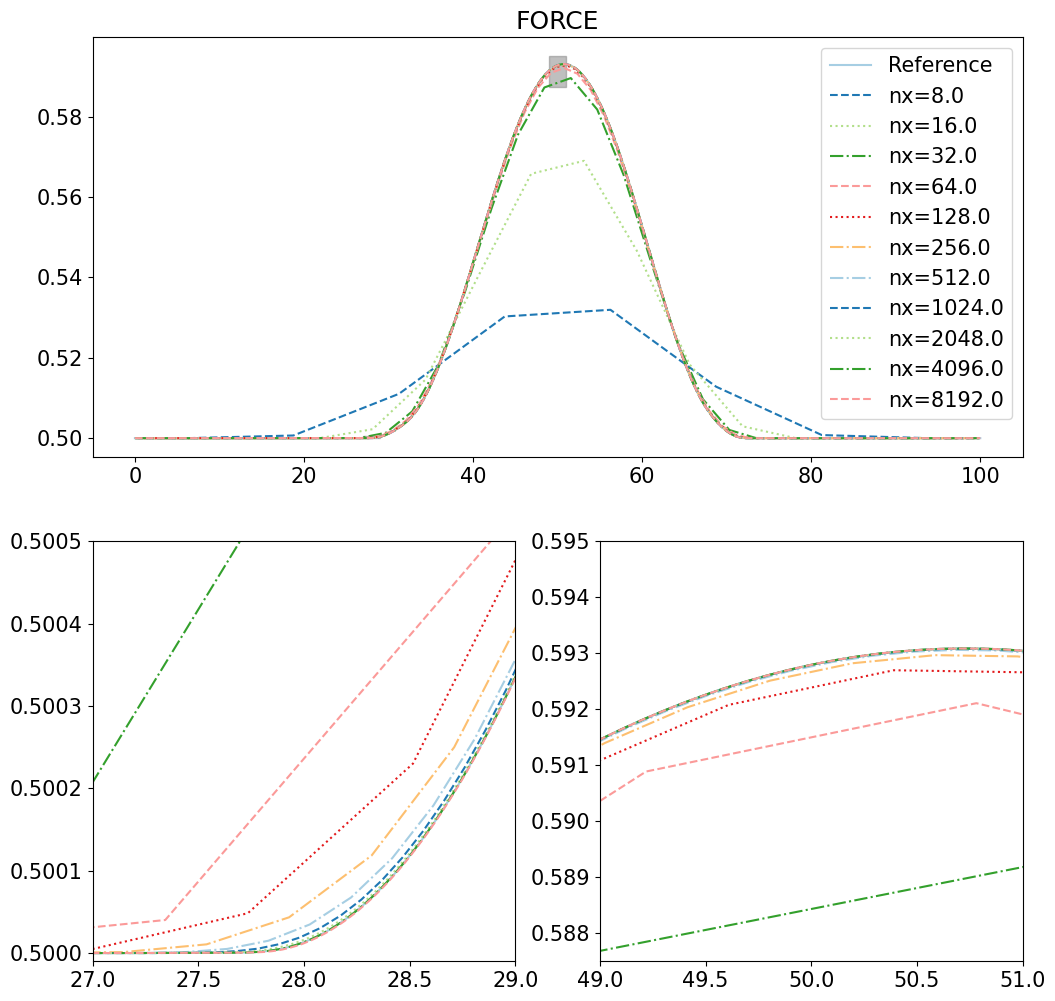

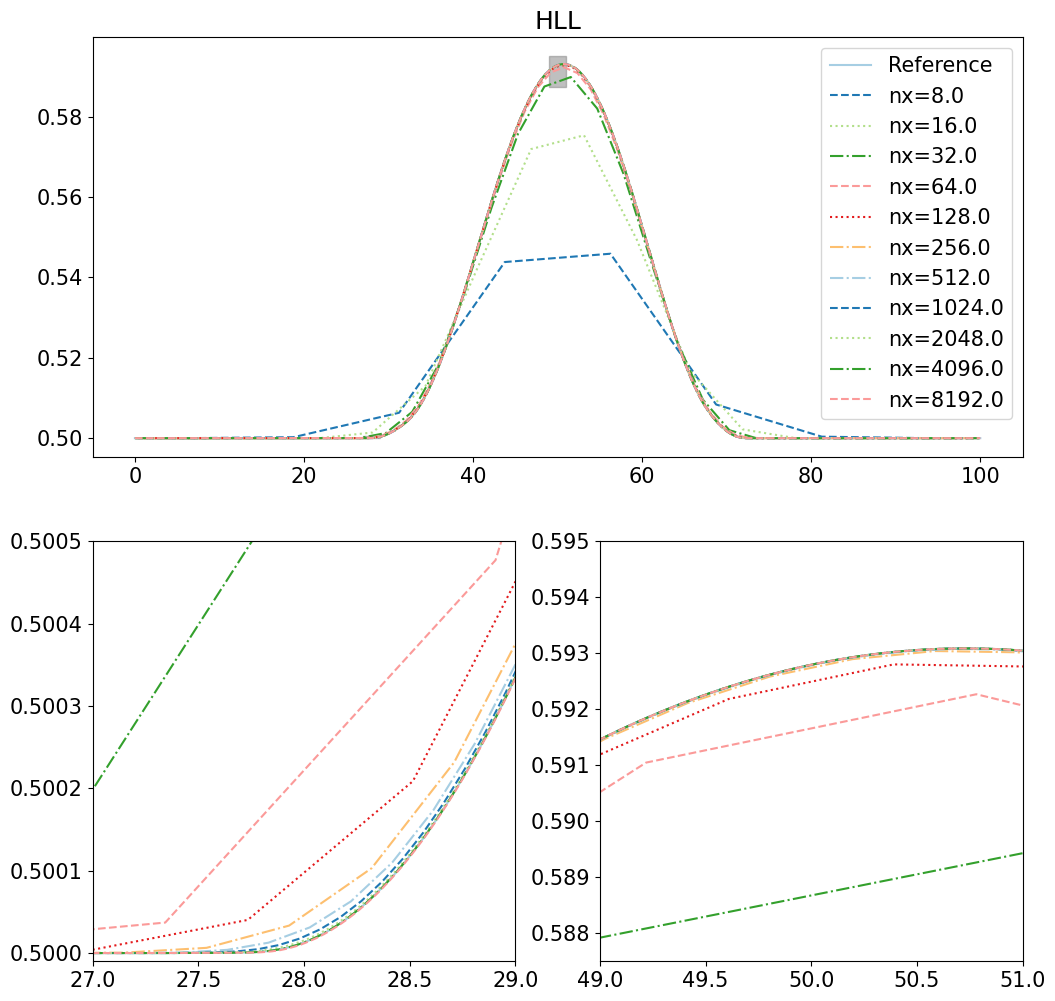

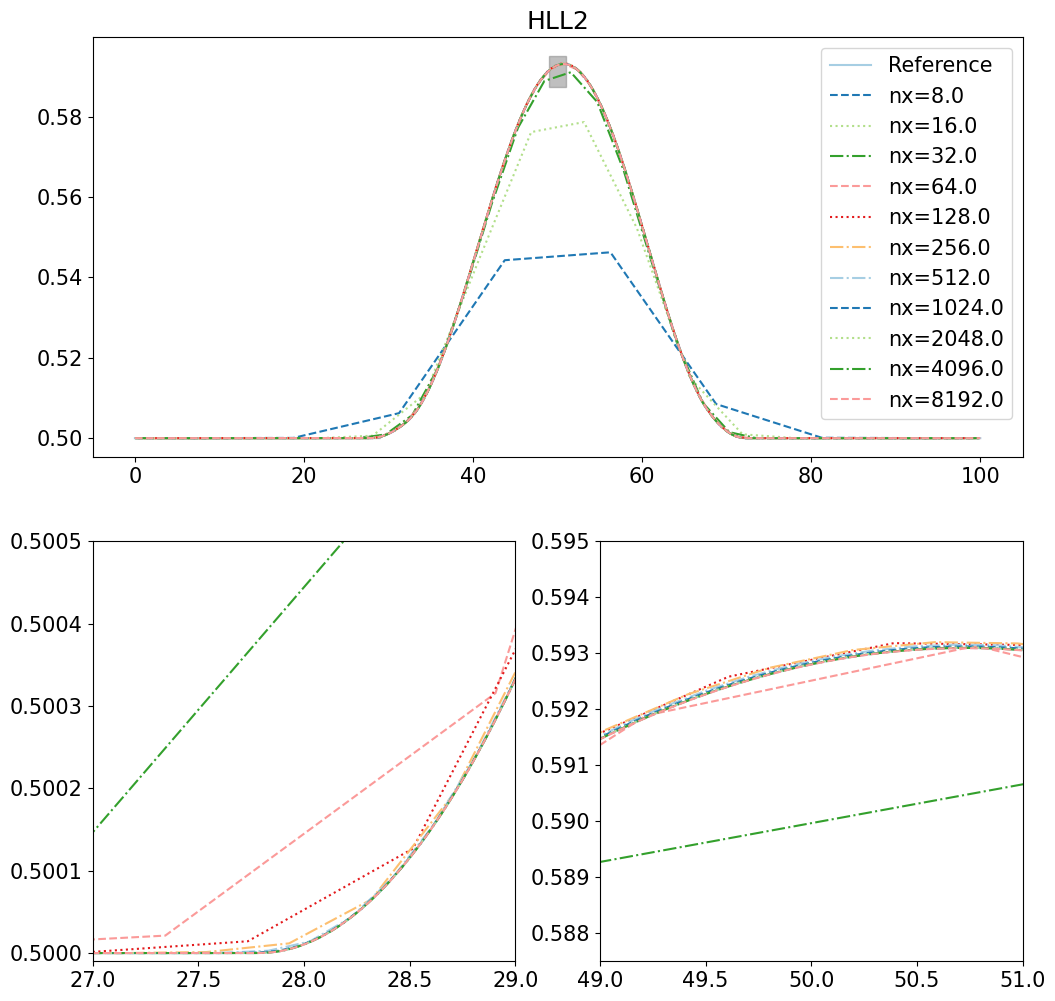

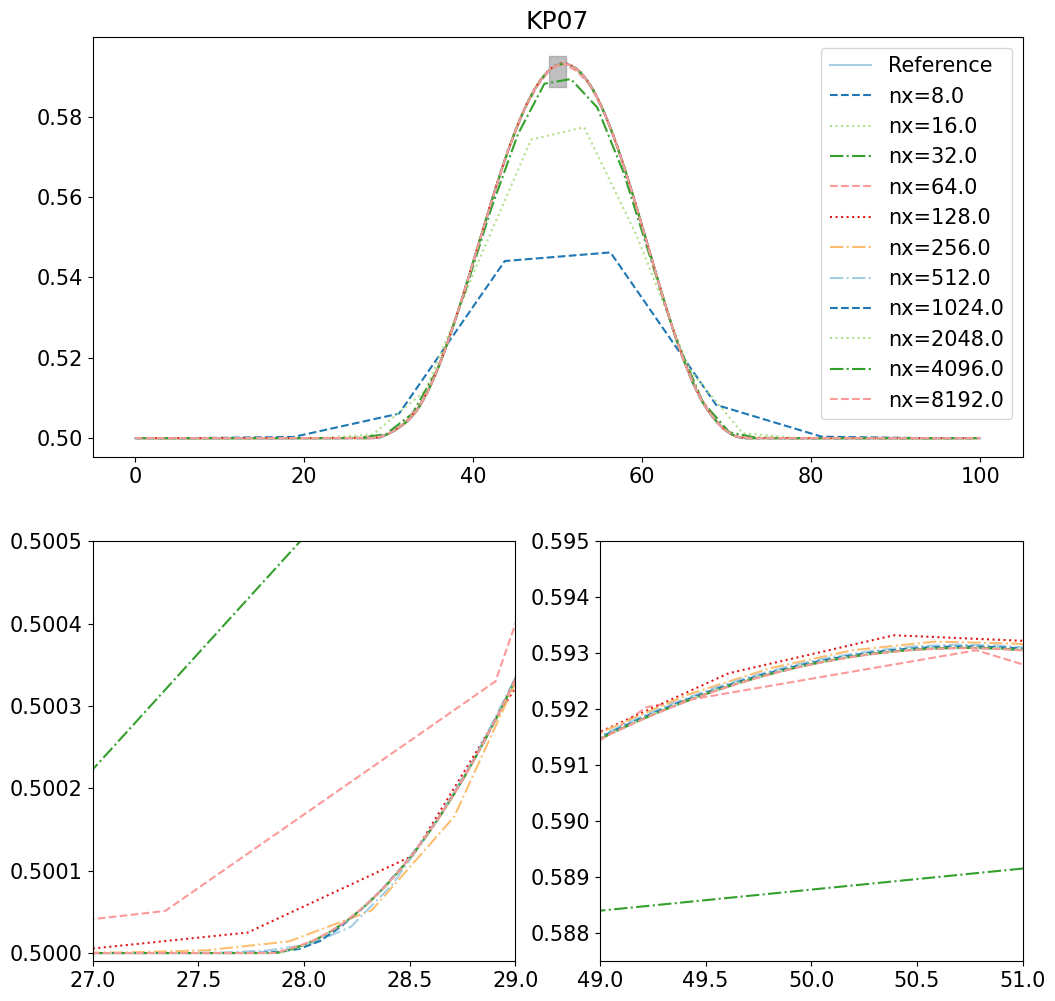

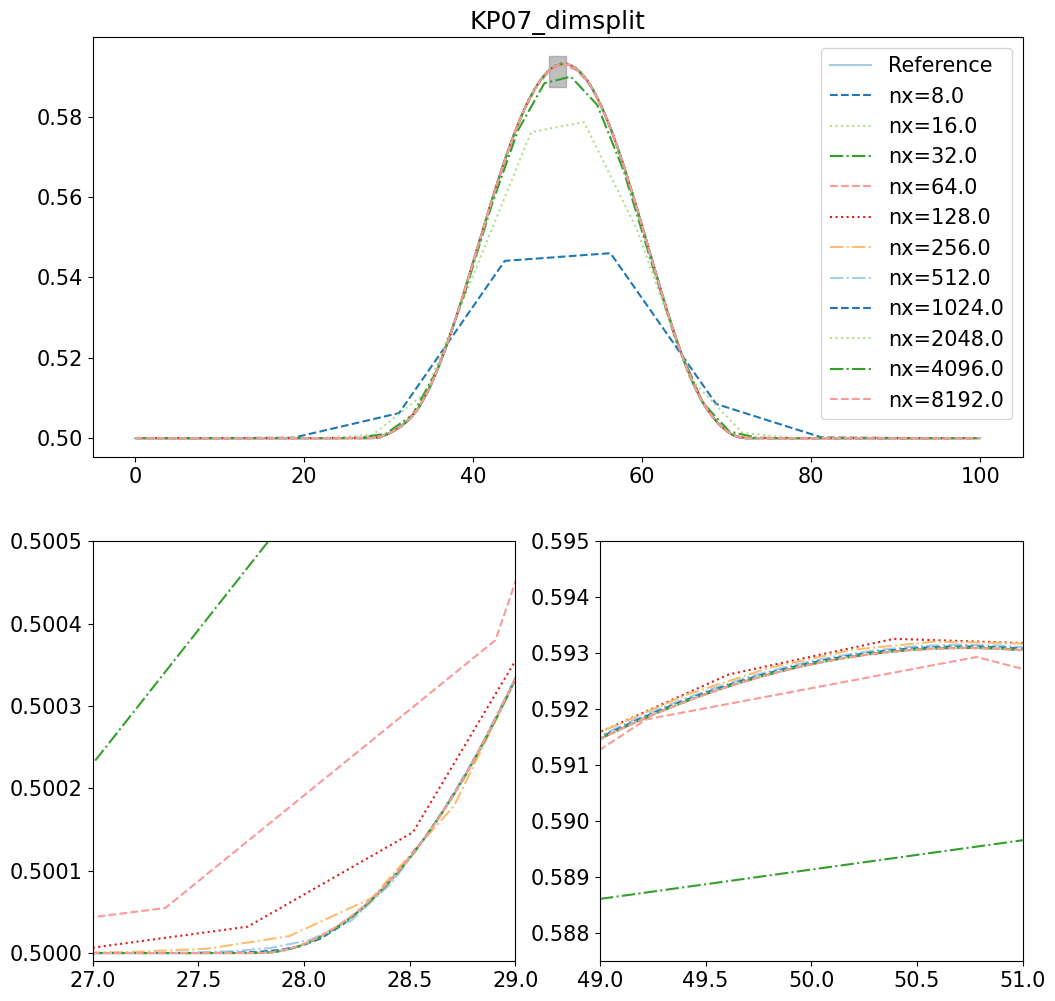

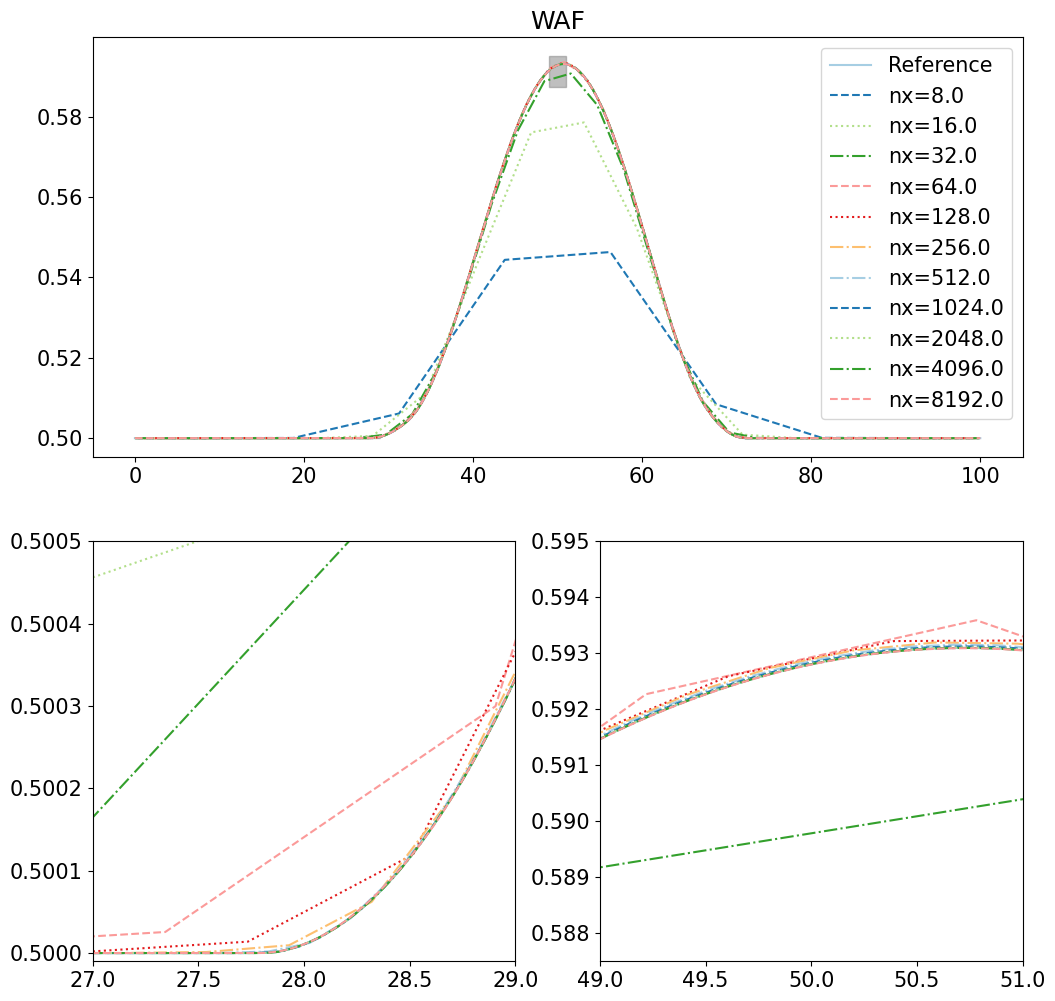

In [24]:

if ic == 'dambreak':
    for i, simulator in enumerate(simulators):
        fig = plt.figure()
    #    miscPlotting.setBwStyles(fig.gca())
    #    plot_solution(simulator, ref_nx, label=str(ref_nx) +" (ref)", c='k', ls='dotted', marker=None, lw=1, alpha=0.5)
        plot_reference("Analytic")
        for nx,ny in zip(ds_x[i], ds_y[i]):
    #        fig.set_prop_cycle(cycler('color', miscPlotting.sns.color_palette()))
            plot_solution(simulator, nx.astype(int), ny.astype(int), label=str(nx) + ',' + str(ny), marker=None, lw=0.5, alpha=0.5)
        plt.xlabel("$x$")
        plt.ylabel("$h$")
        plt.legend()
        plt.title(simulator.label())
        miscPlotting.save_figure(fig, f"solutions_{simulator.__name__}", ic)
elif ic == 'bump':
    for i, simulator in enumerate(simulators):
        fig = plt.figure(figsize=(12, 12))
        gs = gridspec.GridSpec(2, 2)
        ax1 = fig.add_subplot(gs[0,:])
        miscPlotting.setBwStyles(ax1)
        plot_solution(simulator, 4096, 4096, label = 'Reference', linestyle='-', marker=' ')
        for nx, ny in zip(ds_x[i], ds_y[i]):
            plot_solution(simulator, int(nx), int(ny), label= 'nx=' + str(nx), marker=' ')
        for box_x, box_y in boxes:
            x = np.kron(box_x, np.ones((2)))
            y = np.hstack((box_y, box_y[::-1]))
            fig.gca().fill(x, y, fill=True, linestyle='-', color='gray', alpha=0.5)
        plt.title(str(simulator.__name__))
        plt.legend()
        
        ax2 = fig.add_subplot(gs[1,0])
        miscPlotting.setBwStyles(ax2)
        plot_solution(simulator, 4096, 4096, 'Reference', linestyle='-', marker=' ')
        for nx, ny in zip(ds_x[i], ds_y[i]):
            plot_solution(simulator, int(nx), int(ny), label ='nx=' + str(nx), marker=' ')  
        plt.xlim(boxes[0, 0])
        plt.ylim(boxes[0, 1])
        
        ax3 = fig.add_subplot(gs[1,1])
        miscPlotting.setBwStyles(ax3)
        plot_solution(simulator, 4096, 4096, 'Reference', linestyle='-', marker=' ')
        for nx, ny in zip(ds_x[i], ds_y[i]):
            plot_solution(simulator, int(nx), int(ny), label = 'nx=' + str(nx), marker=' ')   
        plt.xlim(boxes[1, 0])
        plt.ylim(boxes[1, 1])
        
        miscPlotting.save_figure(fig, f"solutions_{simulator.__name__}", ic)
